# Formulation Complexity and Reuse Benchmark

This notebook benchmarks three kidney exchange problem (KEP) formulations on the same randomly generated graph structures and objective vectors.

Formulations:

```text
CF     = CF-cycle + CF-chain
Hybrid = CF-cycle + PIEF-chain
PIEF   = PIEF-cycle + PIEF-chain
```

The benchmark is designed to answer two separate questions:

1. **Formulation comparison:** for a fixed graph and fixed weight vectors, which formulation builds and solves faster?
2. **Model reuse comparison:** for a fixed graph structure, how much is gained by building once and updating objective coefficients across many weight vectors?

The default grid below is intentionally small. Use it as a sanity check before running larger experiments on `garnet`.


In [1]:
# Optional in a fresh Colab-style runtime:
# !pip -q install gurobipy numpy pandas matplotlib

from __future__ import annotations

import csv
import itertools
import json
import math
import time
from dataclasses import dataclass
from pathlib import Path

import gurobipy as gp
from gurobipy import GRB
import matplotlib.pyplot as plt
import numpy as np

import pandas as pd

from formulations.common.backend_utils import (
    build_edge_lists,
    build_pief_chain_keys,
    build_pief_cycle_keys,
)

plt.rcParams.update({"figure.dpi": 120, "savefig.dpi": 180})


## 1. Configuration

The active configuration is smoke-scale. For full experiments, expand the grid after the objective consistency check passes.


In [2]:
MAX_CYCLE = 3
MAX_CHAIN = 4

# Fixed-node density sweep.
# Keep the node count fixed so runtime and formulation-size changes are driven
# by edge density rather than mixing node-count and density effects.
NODE_GRID = [50]
DENSITY_GRID = [0.01, 0.05, 0.1, 0.2, 0.5]
NDD_RATIO = 0.05
GRAPH_SEEDS = [42]
NUM_WEIGHTS = 20

TIME_LIMIT = 60.0
THREADS = 1
GUROBI_SEED = 42
FORMULATIONS = ["cf", "hybrid", "pief"]
MODES = ["rebuild", "reuse_reset"]

# Complexity skip logic is disabled for this run so dense cases report
# actual build and solve times rather than SKIPPED_COMPLEXITY rows.
ENABLE_COMPLEXITY_SKIPS = False
MAX_REBUILD_EST_VARS = 30_000
MAX_REUSE_EST_VARS = 120_000
MAX_EST_CONSTRS = 150_000
MAX_CF_REBUILD_CANDIDATES = 25_000
MAX_CF_REUSE_CANDIDATES = 100_000

OUTPUT_DIR = Path(
    "results/formulation_benchmark/"
    "formal_n50_density_sweep_d001_005_010_020_050_seed42_weights20_noskip"
)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print({
    "MAX_CYCLE": MAX_CYCLE,
    "MAX_CHAIN": MAX_CHAIN,
    "NODE_GRID": NODE_GRID,
    "DENSITY_GRID": DENSITY_GRID,
    "NDD_RATIO": NDD_RATIO,
    "GRAPH_SEEDS": GRAPH_SEEDS,
    "NUM_WEIGHTS": NUM_WEIGHTS,
    "TIME_LIMIT": TIME_LIMIT,
    "THREADS": THREADS,
    "FORMULATIONS": FORMULATIONS,
    "MODES": MODES,
    "ENABLE_COMPLEXITY_SKIPS": ENABLE_COMPLEXITY_SKIPS,
    "MAX_REBUILD_EST_VARS": MAX_REBUILD_EST_VARS,
    "MAX_REUSE_EST_VARS": MAX_REUSE_EST_VARS,
    "MAX_EST_CONSTRS": MAX_EST_CONSTRS,
    "MAX_CF_REBUILD_CANDIDATES": MAX_CF_REBUILD_CANDIDATES,
    "MAX_CF_REUSE_CANDIDATES": MAX_CF_REUSE_CANDIDATES,
    "OUTPUT_DIR": str(OUTPUT_DIR),
})


{'MAX_CYCLE': 3, 'MAX_CHAIN': 4, 'NODE_GRID': [50], 'DENSITY_GRID': [0.01, 0.05, 0.1, 0.2, 0.5], 'NDD_RATIO': 0.05, 'GRAPH_SEEDS': [42], 'NUM_WEIGHTS': 20, 'TIME_LIMIT': 60.0, 'THREADS': 1, 'FORMULATIONS': ['cf', 'hybrid', 'pief'], 'MODES': ['rebuild', 'reuse_reset'], 'ENABLE_COMPLEXITY_SKIPS': False, 'MAX_REBUILD_EST_VARS': 30000, 'MAX_REUSE_EST_VARS': 120000, 'MAX_EST_CONSTRS': 150000, 'MAX_CF_REBUILD_CANDIDATES': 25000, 'MAX_CF_REUSE_CANDIDATES': 100000, 'OUTPUT_DIR': 'results/formulation_benchmark/formal_n50_density_sweep_d001_005_010_020_050_seed42_weights20_noskip'}


## 2. Random Graph and Weight Generation

This keeps the same random-graph convention as the old reuse notebook:

```text
source node: any node
recipient node: non-NDD nodes only
self-loops: forbidden
multi-edges: removed by set semantics
NDD nodes: first `num_ndds` nodes
```


In [3]:
def random_graph(num_nodes: int, num_edges: int, num_ndds: int, seed: int):
    rng = np.random.default_rng(seed)
    edges: set[tuple[int, int]] = set()

    max_possible_edges = (num_nodes - 1) * (num_nodes - num_ndds)
    if num_edges > max_possible_edges:
        raise ValueError(
            f"num_edges={num_edges} exceeds max_possible_edges={max_possible_edges}"
        )

    while len(edges) < num_edges:
        src = int(rng.integers(0, num_nodes))
        dst = int(rng.integers(num_ndds, num_nodes))
        if src != dst:
            edges.add((src, dst))

    edge_index = np.array(sorted(edges), dtype=np.int64).T
    is_ndd = np.zeros(num_nodes, dtype=bool)
    is_ndd[:num_ndds] = True
    return edge_index, is_ndd


def random_weights(num_vectors: int, num_edges: int, seed: int):
    return np.random.default_rng(seed).integers(
        0, 101, size=(num_vectors, num_edges), dtype=np.int32
    )


def edge_count_from_density(num_nodes: int, num_ndds: int, density: float):
    max_possible_edges = (num_nodes - 1) * (num_nodes - num_ndds)
    return max(1, int(round(density * max_possible_edges)))


## 3. Candidate and Key Enumeration

These functions compute structural complexity before solving. The counts are logged separately from solve time so runtime can be interpreted rather than just reported.


In [4]:
def enumerate_cycle_candidates(edge_index, is_ndd, num_nodes, max_cycle=3):
    src, dst, outgoing, _ = build_edge_lists(edge_index, num_nodes)
    cycles = []

    def dfs(start, current, path_nodes, path_edges):
        if len(path_edges) >= max_cycle:
            return
        for edge_idx in outgoing[current]:
            nxt = int(dst[edge_idx])
            if bool(is_ndd[nxt]):
                continue
            new_edges = path_edges + [int(edge_idx)]
            if nxt == start and len(new_edges) >= 2:
                cycles.append({"type": "cycle", "nodes": path_nodes.copy(), "edges": new_edges})
            elif nxt not in path_nodes and nxt > start:
                dfs(start, nxt, path_nodes + [nxt], new_edges)

    for start in range(num_nodes):
        if not bool(is_ndd[start]):
            dfs(start, start, [start], [])

    # Canonical DFS should already avoid duplicates; this keeps the result robust.
    unique = {}
    for candidate in cycles:
        key = tuple(candidate["edges"])
        unique[key] = candidate
    return list(unique.values())


def enumerate_chain_candidates(edge_index, is_ndd, num_nodes, max_chain=4):
    src, dst, outgoing, _ = build_edge_lists(edge_index, num_nodes)
    chains = []
    ndd_nodes = [node for node in range(num_nodes) if bool(is_ndd[node])]

    def dfs(current, path_nodes, path_edges):
        if len(path_edges) >= max_chain:
            return
        for edge_idx in outgoing[current]:
            nxt = int(dst[edge_idx])
            if bool(is_ndd[nxt]) or nxt in path_nodes:
                continue
            new_edges = path_edges + [int(edge_idx)]
            new_nodes = path_nodes + [nxt]
            chains.append({"type": "chain", "nodes": new_nodes, "edges": new_edges})
            dfs(nxt, new_nodes, new_edges)

    for ndd in ndd_nodes:
        dfs(ndd, [ndd], [])
    return chains


def graph_complexity_summary(edge_index, is_ndd, num_nodes, max_cycle, max_chain):
    src, dst, outgoing, _ = build_edge_lists(edge_index, num_nodes)
    cycles = enumerate_cycle_candidates(edge_index, is_ndd, num_nodes, max_cycle=max_cycle)
    chains = enumerate_chain_candidates(edge_index, is_ndd, num_nodes, max_chain=max_chain)
    pief_chain_keys = build_pief_chain_keys(src, dst, outgoing, is_ndd, max_chain=max_chain)
    _, _, pief_cycle_keys = build_pief_cycle_keys(
        src=src,
        dst=dst,
        outgoing=outgoing,
        is_ndd_mask=is_ndd,
        num_nodes=num_nodes,
        max_cycle=max_cycle,
    )
    return {
        "num_cycles": len(cycles),
        "num_chains": len(chains),
        "num_pief_chain_keys": len(pief_chain_keys),
        "num_pief_cycle_keys": len(pief_cycle_keys),
    }


## 4. Unified Cached Model Interface

Each formulation returns the same interface:

```text
model
obj_vars
obj_edge_groups
metadata counts
```

Objective updates are therefore identical across formulations.


In [5]:
SKIPPED_COMPLEXITY_STATUS = -100

STATUS_NAMES = {
    GRB.OPTIMAL: "OPTIMAL",
    GRB.TIME_LIMIT: "TIME_LIMIT",
    GRB.INFEASIBLE: "INFEASIBLE",
    GRB.INF_OR_UNBD: "INF_OR_UNBD",
    GRB.UNBOUNDED: "UNBOUNDED",
    GRB.INTERRUPTED: "INTERRUPTED",
    SKIPPED_COMPLEXITY_STATUS: "SKIPPED_COMPLEXITY",
}


@dataclass
class CachedBenchmarkModel:
    formulation: str
    model: gp.Model
    obj_vars: list
    obj_edge_groups: list[tuple[int, ...]]
    metadata: dict

    def update_objective(self, weights):
        weights = np.asarray(weights, dtype=float).flatten()
        obj_values = [float(sum(weights[e] for e in edge_group)) for edge_group in self.obj_edge_groups]
        self.model.setAttr(GRB.Attr.Obj, self.obj_vars, obj_values)
        self.model.update()

    def solve(self, weights, reset_before_solve=False):
        self.update_objective(weights)
        if reset_before_solve:
            self.model.reset()
        t0 = time.perf_counter()
        self.model.optimize()
        solve_wall = time.perf_counter() - t0
        return collect_solve_stats(self, solve_wall)

    def dispose(self):
        self.model.dispose()


def _safe_model_attr(model, attr_name, default=math.nan):
    try:
        return getattr(model, attr_name)
    except Exception:
        return default


def collect_solve_stats(cached: CachedBenchmarkModel, solve_wall: float):
    model = cached.model
    status = int(model.Status)
    has_solution = int(getattr(model, "SolCount", 0)) > 0
    objective = float(model.ObjVal) if has_solution else math.nan
    mip_gap = _safe_model_attr(model, "MIPGap", math.nan) if has_solution else math.nan
    return {
        "formulation": cached.formulation,
        "status": status,
        "status_name": STATUS_NAMES.get(status, str(status)),
        "is_optimal": status == GRB.OPTIMAL,
        "has_solution": has_solution,
        "objective": objective,
        "mip_gap": float(mip_gap) if not math.isnan(mip_gap) else math.nan,
        "node_count": float(_safe_model_attr(model, "NodeCount", math.nan)),
        "gurobi_runtime": float(_safe_model_attr(model, "Runtime", math.nan)),
        "solve_wall": solve_wall,
        "num_vars": int(model.NumVars),
        "num_constrs": int(model.NumConstrs),
        **cached.metadata,
    }


def configure_model(model, time_limit=TIME_LIMIT, threads=THREADS, seed=GUROBI_SEED):
    model.Params.OutputFlag = 0
    model.Params.TimeLimit = time_limit
    model.Params.Threads = threads
    model.Params.Seed = seed
    model.ModelSense = GRB.MAXIMIZE


### CF Builder: CF-cycle + CF-chain


In [6]:
def build_cf_cached(edge_index, is_ndd, num_nodes, max_cycle=3, max_chain=4, env=None):
    t_pre = time.perf_counter()
    cycles = enumerate_cycle_candidates(edge_index, is_ndd, num_nodes, max_cycle=max_cycle)
    chains = enumerate_chain_candidates(edge_index, is_ndd, num_nodes, max_chain=max_chain)
    candidates = cycles + chains
    preprocess_wall = time.perf_counter() - t_pre

    t_build = time.perf_counter()
    model = gp.Model("KEP_CF_CYCLE_CF_CHAIN", env=env)
    configure_model(model)
    y = model.addVars(len(candidates), vtype=GRB.BINARY, name="cand")

    obj_vars = []
    obj_edge_groups = []
    for idx, candidate in enumerate(candidates):
        obj_vars.append(y[idx])
        obj_edge_groups.append(tuple(int(e) for e in candidate["edges"]))

    for node in range(num_nodes):
        involved = [idx for idx, candidate in enumerate(candidates) if node in candidate["nodes"]]
        if involved:
            model.addConstr(gp.quicksum(y[idx] for idx in involved) <= 1, name=f"node_once_{node}")

    model.update()
    gurobi_build_wall = time.perf_counter() - t_build
    return CachedBenchmarkModel(
        formulation="cf",
        model=model,
        obj_vars=obj_vars,
        obj_edge_groups=obj_edge_groups,
        metadata={
            "preprocess_wall": preprocess_wall,
            "gurobi_build_wall": gurobi_build_wall,
            "build_wall": preprocess_wall + gurobi_build_wall,
            "num_cycles": len(cycles),
            "num_chains": len(chains),
            "num_pief_chain_keys": math.nan,
            "num_pief_cycle_keys": math.nan,
        },
    )


### Hybrid Builder: CF-cycle + PIEF-chain


In [7]:
def build_hybrid_cached(edge_index, is_ndd, num_nodes, max_cycle=3, max_chain=4, env=None):
    t_pre = time.perf_counter()
    src, dst, outgoing, _ = build_edge_lists(edge_index, num_nodes)
    cycles = enumerate_cycle_candidates(edge_index, is_ndd, num_nodes, max_cycle=max_cycle)
    chain_keys = build_pief_chain_keys(src, dst, outgoing, is_ndd, max_chain=max_chain)
    preprocess_wall = time.perf_counter() - t_pre

    chain_incoming = {}
    chain_outgoing = {}
    for edge_idx, position in chain_keys:
        chain_incoming.setdefault((int(dst[edge_idx]), position), []).append((edge_idx, position))
        chain_outgoing.setdefault((int(src[edge_idx]), position), []).append((edge_idx, position))

    t_build = time.perf_counter()
    model = gp.Model("KEP_CF_CYCLE_PIEF_CHAIN", env=env)
    configure_model(model)
    cycle_vars = model.addVars(len(cycles), vtype=GRB.BINARY, name="cycle")
    chain_vars = model.addVars(chain_keys, vtype=GRB.BINARY, name="chain")

    obj_vars = []
    obj_edge_groups = []
    for idx, candidate in enumerate(cycles):
        obj_vars.append(cycle_vars[idx])
        obj_edge_groups.append(tuple(int(e) for e in candidate["edges"]))
    for edge_idx, position in chain_keys:
        obj_vars.append(chain_vars[edge_idx, position])
        obj_edge_groups.append((int(edge_idx),))

    pair_nodes = [node for node in range(num_nodes) if not bool(is_ndd[node])]
    ndd_nodes = [node for node in range(num_nodes) if bool(is_ndd[node])]

    for pair_node in pair_nodes:
        cycle_usage = gp.quicksum(
            cycle_vars[idx]
            for idx, candidate in enumerate(cycles)
            if pair_node in candidate["nodes"]
        )
        chain_usage = gp.quicksum(
            chain_vars[edge_idx, position]
            for edge_idx, position in chain_keys
            if int(dst[edge_idx]) == pair_node
        )
        model.addConstr(cycle_usage + chain_usage <= 1, name=f"pair_once_{pair_node}")

    for ndd_node in ndd_nodes:
        model.addConstr(
            gp.quicksum(
                chain_vars[edge_idx, 1]
                for edge_idx, position in chain_keys
                if position == 1 and int(src[edge_idx]) == ndd_node
            ) <= 1,
            name=f"ndd_once_{ndd_node}",
        )

    for pair_node in pair_nodes:
        for position in range(2, max_chain + 1):
            outgoing_now = gp.quicksum(
                chain_vars[edge_idx, position]
                for edge_idx, _ in chain_outgoing.get((pair_node, position), [])
            )
            incoming_prev = gp.quicksum(
                chain_vars[edge_idx, position - 1]
                for edge_idx, _ in chain_incoming.get((pair_node, position - 1), [])
            )
            model.addConstr(outgoing_now <= incoming_prev, name=f"chain_flow_{pair_node}_{position}")

    model.update()
    gurobi_build_wall = time.perf_counter() - t_build
    return CachedBenchmarkModel(
        formulation="hybrid",
        model=model,
        obj_vars=obj_vars,
        obj_edge_groups=obj_edge_groups,
        metadata={
            "preprocess_wall": preprocess_wall,
            "gurobi_build_wall": gurobi_build_wall,
            "build_wall": preprocess_wall + gurobi_build_wall,
            "num_cycles": len(cycles),
            "num_chains": math.nan,
            "num_pief_chain_keys": len(chain_keys),
            "num_pief_cycle_keys": math.nan,
        },
    )


### PIEF Builder: PIEF-cycle + PIEF-chain


In [8]:
def build_pief_cached(edge_index, is_ndd, num_nodes, max_cycle=3, max_chain=4, env=None):
    t_pre = time.perf_counter()
    src, dst, outgoing, _ = build_edge_lists(edge_index, num_nodes)
    chain_keys = build_pief_chain_keys(src, dst, outgoing, is_ndd, max_chain=max_chain)
    cycle_start_nodes, cycle_order_rank, cycle_keys = build_pief_cycle_keys(
        src=src,
        dst=dst,
        outgoing=outgoing,
        is_ndd_mask=is_ndd,
        num_nodes=num_nodes,
        max_cycle=max_cycle,
    )
    preprocess_wall = time.perf_counter() - t_pre

    chain_incoming = {}
    chain_outgoing = {}
    for edge_idx, position in chain_keys:
        chain_incoming.setdefault((int(dst[edge_idx]), position), []).append((edge_idx, position))
        chain_outgoing.setdefault((int(src[edge_idx]), position), []).append((edge_idx, position))

    cycle_incoming = {}
    cycle_outgoing = {}
    for start_node, edge_idx, position in cycle_keys:
        cycle_incoming.setdefault((start_node, int(dst[edge_idx]), position), []).append((start_node, edge_idx, position))
        cycle_outgoing.setdefault((start_node, int(src[edge_idx]), position), []).append((start_node, edge_idx, position))

    t_build = time.perf_counter()
    model = gp.Model("KEP_PIEF_CYCLE_PIEF_CHAIN", env=env)
    configure_model(model)
    chain_vars = model.addVars(chain_keys, vtype=GRB.BINARY, name="chain")
    cycle_vars = model.addVars(cycle_keys, vtype=GRB.BINARY, name="cycle")

    obj_vars = []
    obj_edge_groups = []
    for edge_idx, position in chain_keys:
        obj_vars.append(chain_vars[edge_idx, position])
        obj_edge_groups.append((int(edge_idx),))
    for start_node, edge_idx, position in cycle_keys:
        obj_vars.append(cycle_vars[start_node, edge_idx, position])
        obj_edge_groups.append((int(edge_idx),))

    pair_nodes = [node for node in range(num_nodes) if not bool(is_ndd[node])]
    ndd_nodes = [node for node in range(num_nodes) if bool(is_ndd[node])]

    for pair_node in pair_nodes:
        cycle_usage = gp.quicksum(
            cycle_vars[start_node, edge_idx, position]
            for start_node, edge_idx, position in cycle_keys
            if int(dst[edge_idx]) == pair_node
        )
        chain_usage = gp.quicksum(
            chain_vars[edge_idx, position]
            for edge_idx, position in chain_keys
            if int(dst[edge_idx]) == pair_node
        )
        model.addConstr(cycle_usage + chain_usage <= 1, name=f"pair_once_{pair_node}")

    for ndd_node in ndd_nodes:
        model.addConstr(
            gp.quicksum(
                chain_vars[edge_idx, 1]
                for edge_idx, position in chain_keys
                if position == 1 and int(src[edge_idx]) == ndd_node
            ) <= 1,
            name=f"ndd_once_{ndd_node}",
        )

    for pair_node in pair_nodes:
        for position in range(2, max_chain + 1):
            outgoing_now = gp.quicksum(
                chain_vars[edge_idx, position]
                for edge_idx, _ in chain_outgoing.get((pair_node, position), [])
            )
            incoming_prev = gp.quicksum(
                chain_vars[edge_idx, position - 1]
                for edge_idx, _ in chain_incoming.get((pair_node, position - 1), [])
            )
            model.addConstr(outgoing_now <= incoming_prev, name=f"chain_flow_{pair_node}_{position}")

    for start_node in cycle_start_nodes:
        start_rank = cycle_order_rank[start_node]
        for pair_node in cycle_start_nodes:
            if cycle_order_rank[pair_node] <= start_rank:
                continue
            for position in range(1, max_cycle):
                outgoing_now = gp.quicksum(
                    cycle_vars[key]
                    for key in cycle_outgoing.get((start_node, pair_node, position + 1), [])
                )
                incoming_prev = gp.quicksum(
                    cycle_vars[key]
                    for key in cycle_incoming.get((start_node, pair_node, position), [])
                )
                model.addConstr(
                    incoming_prev == outgoing_now,
                    name=f"cycle_flow_{start_node}_{pair_node}_{position}",
                )

    model.update()
    gurobi_build_wall = time.perf_counter() - t_build
    return CachedBenchmarkModel(
        formulation="pief",
        model=model,
        obj_vars=obj_vars,
        obj_edge_groups=obj_edge_groups,
        metadata={
            "preprocess_wall": preprocess_wall,
            "gurobi_build_wall": gurobi_build_wall,
            "build_wall": preprocess_wall + gurobi_build_wall,
            "num_cycles": math.nan,
            "num_chains": math.nan,
            "num_pief_chain_keys": len(chain_keys),
            "num_pief_cycle_keys": len(cycle_keys),
        },
    )


## 5. Benchmark Runners

- `rebuild`: build a fresh model for each weight vector.
- `reuse_reset`: build once, update objective, call `model.reset()` before each solve.
- `reuse_warm`: build once, update objective, keep Gurobi's previous solve information.


In [9]:

def build_model_by_formulation(formulation, edge_index, is_ndd, num_nodes, max_cycle, max_chain, env):
    if formulation == "cf":
        return build_cf_cached(edge_index, is_ndd, num_nodes, max_cycle=max_cycle, max_chain=max_chain, env=env)
    if formulation == "hybrid":
        return build_hybrid_cached(edge_index, is_ndd, num_nodes, max_cycle=max_cycle, max_chain=max_chain, env=env)
    if formulation == "pief":
        return build_pief_cached(edge_index, is_ndd, num_nodes, max_cycle=max_cycle, max_chain=max_chain, env=env)
    raise ValueError(f"Unknown formulation: {formulation}")


def estimate_formulation_size(formulation, graph_summary, num_nodes, max_cycle=MAX_CYCLE, max_chain=MAX_CHAIN, ndd_ratio=NDD_RATIO):
    num_pairs = num_nodes - max(1, round(ndd_ratio * num_nodes))
    num_ndds = max(1, round(ndd_ratio * num_nodes))
    num_cycles = int(graph_summary["num_cycles"])
    num_chains = int(graph_summary["num_chains"])
    num_pief_chain_keys = int(graph_summary["num_pief_chain_keys"])
    num_pief_cycle_keys = int(graph_summary["num_pief_cycle_keys"])

    if formulation == "cf":
        est_vars = num_cycles + num_chains
        est_constrs = num_nodes
    elif formulation == "hybrid":
        est_vars = num_cycles + num_pief_chain_keys
        est_constrs = num_pairs + num_ndds + num_pairs * max(0, max_chain - 1)
    elif formulation == "pief":
        est_vars = num_pief_cycle_keys + num_pief_chain_keys
        # Matches the current PIEF builder style, which creates cycle-flow
        # constraints over ordered start-node / pair-node / position triples.
        est_cycle_flow = (num_pairs * max(0, num_pairs - 1) // 2) * max(0, max_cycle - 1)
        est_chain_flow = num_pairs * max(0, max_chain - 1)
        est_constrs = num_pairs + num_ndds + est_chain_flow + est_cycle_flow
    else:
        raise ValueError(f"Unknown formulation: {formulation}")

    return {
        "estimated_num_vars": int(est_vars),
        "estimated_num_constrs": int(est_constrs),
        "estimated_cf_candidates": int(num_cycles + num_chains),
    }


def complexity_skip_reason(formulation, mode, graph_summary, num_nodes):
    if not ENABLE_COMPLEXITY_SKIPS:
        return None, estimate_formulation_size(formulation, graph_summary, num_nodes)

    est = estimate_formulation_size(formulation, graph_summary, num_nodes)
    est_vars = est["estimated_num_vars"]
    est_constrs = est["estimated_num_constrs"]
    cf_candidates = est["estimated_cf_candidates"]

    if formulation == "cf" and mode == "rebuild" and cf_candidates > MAX_CF_REBUILD_CANDIDATES:
        return f"cf_candidates>{MAX_CF_REBUILD_CANDIDATES}", est
    if formulation == "cf" and mode.startswith("reuse") and cf_candidates > MAX_CF_REUSE_CANDIDATES:
        return f"cf_candidates>{MAX_CF_REUSE_CANDIDATES}", est
    if mode == "rebuild" and est_vars > MAX_REBUILD_EST_VARS:
        return f"estimated_num_vars>{MAX_REBUILD_EST_VARS}", est
    if mode.startswith("reuse") and est_vars > MAX_REUSE_EST_VARS:
        return f"estimated_num_vars>{MAX_REUSE_EST_VARS}", est
    if est_constrs > MAX_EST_CONSTRS:
        return f"estimated_num_constrs>{MAX_EST_CONSTRS}", est
    return None, est


def make_skipped_row(formulation, mode, reason, est, graph_context, num_weights):
    return {
        "formulation": formulation,
        "mode": mode,
        "weight_id": -1,
        "status": SKIPPED_COMPLEXITY_STATUS,
        "status_name": STATUS_NAMES[SKIPPED_COMPLEXITY_STATUS],
        "is_optimal": False,
        "has_solution": False,
        "objective": math.nan,
        "mip_gap": math.nan,
        "node_count": math.nan,
        "gurobi_runtime": 0.0,
        "solve_wall": 0.0,
        "preprocess_wall": 0.0,
        "gurobi_build_wall": 0.0,
        "build_wall": 0.0,
        "total_wall": 0.0,
        "num_vars": est["estimated_num_vars"],
        "num_constrs": est["estimated_num_constrs"],
        "estimated_num_vars": est["estimated_num_vars"],
        "estimated_num_constrs": est["estimated_num_constrs"],
        "estimated_cf_candidates": est["estimated_cf_candidates"],
        "skip_reason": reason,
        "num_weight_vectors_planned": num_weights,
        **graph_context,
    }


def run_rebuild_benchmark_one_graph(formulation, edge_index, is_ndd, num_nodes, weights, max_cycle, max_chain, env):
    rows = []
    for weight_id, weights_one in enumerate(weights):
        cached = build_model_by_formulation(formulation, edge_index, is_ndd, num_nodes, max_cycle, max_chain, env)
        try:
            row = cached.solve(weights_one, reset_before_solve=False)
            row.update({
                "mode": "rebuild",
                "weight_id": weight_id,
                "total_wall": row["build_wall"] + row["solve_wall"],
                "skip_reason": "",
                "num_weight_vectors_planned": len(weights),
            })
            rows.append(row)
        finally:
            cached.dispose()
    return rows


def run_reuse_benchmark_one_graph(formulation, edge_index, is_ndd, num_nodes, weights, max_cycle, max_chain, env, reset_before_solve):
    rows = []
    cached = build_model_by_formulation(formulation, edge_index, is_ndd, num_nodes, max_cycle, max_chain, env)
    try:
        mode = "reuse_reset" if reset_before_solve else "reuse_warm"
        initial_build = dict(cached.metadata)
        for weight_id, weights_one in enumerate(weights):
            row = cached.solve(weights_one, reset_before_solve=reset_before_solve)
            if weight_id == 0:
                row.update(initial_build)
            else:
                row.update({
                    "preprocess_wall": 0.0,
                    "gurobi_build_wall": 0.0,
                    "build_wall": 0.0,
                })
            row.update({
                "mode": mode,
                "weight_id": weight_id,
                "total_wall": row["build_wall"] + row["solve_wall"],
                "skip_reason": "",
                "num_weight_vectors_planned": len(weights),
            })
            rows.append(row)
    finally:
        cached.dispose()
    return rows


def run_benchmark(node_grid=NODE_GRID, density_grid=DENSITY_GRID, graph_seeds=GRAPH_SEEDS, num_weights=NUM_WEIGHTS, modes=MODES, ndd_ratio=NDD_RATIO, checkpoint_path=None):
    all_rows = []
    if checkpoint_path is None:
        checkpoint_path = OUTPUT_DIR / "formulation_benchmark_results_partial.csv"
    env = gp.Env(empty=True)
    env.setParam("OutputFlag", 0)
    env.setParam("Seed", GUROBI_SEED)
    env.start()

    try:
        for num_nodes, density, graph_seed in itertools.product(node_grid, density_grid, graph_seeds):
            num_ndds = max(1, round(ndd_ratio * num_nodes))
            num_edges = edge_count_from_density(num_nodes, num_ndds, density)
            edge_index, is_ndd = random_graph(num_nodes, num_edges, num_ndds, seed=graph_seed)
            weights = random_weights(num_weights, edge_index.shape[1], seed=100000 + graph_seed)
            graph_summary = graph_complexity_summary(edge_index, is_ndd, num_nodes, MAX_CYCLE, MAX_CHAIN)
            actual_density = edge_index.shape[1] / ((num_nodes - 1) * (num_nodes - num_ndds))

            graph_context = {
                "num_nodes": num_nodes,
                "num_edges": int(edge_index.shape[1]),
                "target_density": density,
                "actual_density": actual_density,
                "num_ndds": num_ndds,
                "graph_seed": graph_seed,
                **graph_summary,
            }
            print("graph", graph_context, flush=True)

            for formulation in FORMULATIONS:
                if "rebuild" in modes:
                    reason, est = complexity_skip_reason(formulation, "rebuild", graph_summary, num_nodes)
                    if reason:
                        print(f"  skip formulation={formulation} mode=rebuild reason={reason} est={est}", flush=True)
                        all_rows.append(make_skipped_row(formulation, "rebuild", reason, est, graph_context, num_weights))
                    else:
                        rows = run_rebuild_benchmark_one_graph(
                            formulation, edge_index, is_ndd, num_nodes, weights, MAX_CYCLE, MAX_CHAIN, env
                        )
                        for row in rows:
                            row.update(graph_context)
                        all_rows.extend(rows)

                if "reuse_reset" in modes:
                    reason, est = complexity_skip_reason(formulation, "reuse_reset", graph_summary, num_nodes)
                    if reason:
                        print(f"  skip formulation={formulation} mode=reuse_reset reason={reason} est={est}", flush=True)
                        all_rows.append(make_skipped_row(formulation, "reuse_reset", reason, est, graph_context, num_weights))
                    else:
                        rows = run_reuse_benchmark_one_graph(
                            formulation, edge_index, is_ndd, num_nodes, weights, MAX_CYCLE, MAX_CHAIN, env, reset_before_solve=True
                        )
                        for row in rows:
                            row.update(graph_context)
                        all_rows.extend(rows)

                if "reuse_warm" in modes:
                    reason, est = complexity_skip_reason(formulation, "reuse_warm", graph_summary, num_nodes)
                    if reason:
                        print(f"  skip formulation={formulation} mode=reuse_warm reason={reason} est={est}", flush=True)
                        all_rows.append(make_skipped_row(formulation, "reuse_warm", reason, est, graph_context, num_weights))
                    else:
                        rows = run_reuse_benchmark_one_graph(
                            formulation, edge_index, is_ndd, num_nodes, weights, MAX_CYCLE, MAX_CHAIN, env, reset_before_solve=False
                        )
                        for row in rows:
                            row.update(graph_context)
                        all_rows.extend(rows)

            if checkpoint_path is not None:
                write_rows_csv(checkpoint_path, all_rows)
                print(f"  checkpoint saved {checkpoint_path} rows={len(all_rows)}", flush=True)
    finally:
        env.dispose()

    return all_rows


In [10]:
def write_rows_csv(path, rows):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    rows = list(rows)
    if not rows:
        path.write_text("", encoding="utf-8")
        return path
    fieldnames = sorted({key for row in rows for key in row.keys()})
    with path.open("w", newline="", encoding="utf-8") as handle:
        writer = csv.DictWriter(handle, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(rows)
    return path


def as_records(table):
    if pd is not None and hasattr(table, "to_dict"):
        return table.to_dict("records")
    return list(table)


def show_table(rows, n=5):
    rows = list(rows)
    if pd is not None:
        return pd.DataFrame(rows).head(n)
    for row in rows[:n]:
        print(row)
    return rows[:n]


def median(values):
    values = sorted(float(v) for v in values if not math.isnan(float(v)))
    if not values:
        return math.nan
    mid = len(values) // 2
    if len(values) % 2:
        return values[mid]
    return 0.5 * (values[mid - 1] + values[mid])


## 6. Run Smoke Benchmark

This cell writes a CSV under `results/formulation_benchmark/`. Keep this small until the consistency check passes.


In [11]:
rows = run_benchmark()
results_path = OUTPUT_DIR / "formulation_benchmark_results.csv"
write_rows_csv(results_path, rows)
print(f"saved {results_path}")
df = pd.DataFrame(rows) if pd is not None else rows
show_table(rows)


graph {'num_nodes': 50, 'num_edges': 24, 'target_density': 0.01, 'actual_density': 0.01020408163265306, 'num_ndds': 2, 'graph_seed': 42, 'num_cycles': 0, 'num_chains': 0, 'num_pief_chain_keys': 0, 'num_pief_cycle_keys': 0}
  checkpoint saved results/formulation_benchmark/formal_n50_density_sweep_d001_005_010_020_050_seed42_weights20_noskip/formulation_benchmark_results_partial.csv rows=120
graph {'num_nodes': 50, 'num_edges': 118, 'target_density': 0.05, 'actual_density': 0.050170068027210885, 'num_ndds': 2, 'graph_seed': 42, 'num_cycles': 5, 'num_chains': 116, 'num_pief_chain_keys': 83, 'num_pief_cycle_keys': 12}
  checkpoint saved results/formulation_benchmark/formal_n50_density_sweep_d001_005_010_020_050_seed42_weights20_noskip/formulation_benchmark_results_partial.csv rows=240
graph {'num_nodes': 50, 'num_edges': 235, 'target_density': 0.1, 'actual_density': 0.09991496598639456, 'num_ndds': 2, 'graph_seed': 42, 'num_cycles': 45, 'num_chains': 1391, 'num_pief_chain_keys': 466, 'num_

,formulation,status,status_name,is_optimal,has_solution,objective,mip_gap,node_count,gurobi_runtime,solve_wall,...,weight_id,total_wall,skip_reason,num_weight_vectors_planned,num_nodes,num_edges,target_density,actual_density,num_ndds,graph_seed
0,cf,2,OPTIMAL,True,True,-0.0,NaN,0.0,0.000281,0.000309,...,0,0.000625,,20,50,24,0.01,0.010204,2,42
1,cf,2,OPTIMAL,True,True,-0.0,NaN,0.0,0.000143,0.000148,...,1,0.000290,,20,50,24,0.01,0.010204,2,42
2,cf,2,OPTIMAL,True,True,-0.0,NaN,0.0,0.000124,0.000129,...,2,0.000223,,20,50,24,0.01,0.010204,2,42
3,cf,2,OPTIMAL,True,True,-0.0,NaN,0.0,0.000132,0.000137,...,3,0.000319,,20,50,24,0.01,0.010204,2,42
4,cf,2,OPTIMAL,True,True,-0.0,NaN,0.0,0.000137,0.000142,...,4,0.000229,,20,50,24,0.01,0.010204,2,42


## 7. Objective Consistency Check

For identical graph and weights, the three formulations should agree when all solve to optimality. A mismatch means the benchmark should stop and the formulation implementation should be inspected before interpreting runtime.


In [12]:
def objective_consistency_check(table, tol=1e-5):
    records = [row for row in as_records(table) if bool(row.get("is_optimal"))]
    group_cols = [
        "num_nodes",
        "num_edges",
        "target_density",
        "graph_seed",
        "weight_id",
        "mode",
    ]
    groups = {}
    for row in records:
        key = tuple(row[col] for col in group_cols)
        groups.setdefault(key, []).append(row)

    rows = []
    for key, group in groups.items():
        by_formulation = {row["formulation"]: row for row in group}
        if set(by_formulation) != {"cf", "hybrid", "pief"}:
            continue
        objs = {name: float(row["objective"]) for name, row in by_formulation.items()}
        max_diff = max(objs.values()) - min(objs.values())
        rows.append({
            **dict(zip(group_cols, key)),
            "cf_objective": objs["cf"],
            "hybrid_objective": objs["hybrid"],
            "pief_objective": objs["pief"],
            "max_obj_diff": max_diff,
            "pass": max_diff <= tol,
        })
    return rows

check_rows = objective_consistency_check(df)
check_path = OUTPUT_DIR / "objective_consistency_check.csv"
write_rows_csv(check_path, check_rows)
print(f"saved {check_path}")
if check_rows:
    pass_rate = sum(bool(row["pass"]) for row in check_rows) / len(check_rows)
    print("pass_rate", pass_rate)
    show_table(sorted(check_rows, key=lambda row: row["max_obj_diff"], reverse=True))
else:
    print("no complete optimal groups")


saved results/formulation_benchmark/formal_n50_density_sweep_d001_005_010_020_050_seed42_weights20_noskip/objective_consistency_check.csv
pass_rate 0.99


## 8. Runtime Summaries

There are two useful levels of aggregation:

1. **Per-solve median**: diagnostic view over individual optimization calls.
2. **Per-graph aggregate over all weights**: the main view for reuse experiments, because it charges the one-time build cost once and then sums solve time across all objective vectors for that fixed graph.


In [13]:
def summarize_per_solve_results(table):
    records = as_records(table)
    group_cols = ["mode", "num_nodes", "target_density", "formulation"]
    groups = {}
    for row in records:
        key = tuple(row[col] for col in group_cols)
        groups.setdefault(key, []).append(row)

    summary_rows = []
    for key, group in groups.items():
        summary_rows.append({
            **dict(zip(group_cols, key)),
            "median_total_wall": median(row["total_wall"] for row in group),
            "median_build_wall": median(row["build_wall"] for row in group),
            "median_preprocess_wall": median(row["preprocess_wall"] for row in group),
            "median_solve_wall": median(row["solve_wall"] for row in group),
            "median_gurobi_runtime": median(row["gurobi_runtime"] for row in group),
            "median_vars": median(row["num_vars"] for row in group),
            "median_constrs": median(row["num_constrs"] for row in group),
            "optimal_rate": sum(bool(row["is_optimal"]) for row in group) / len(group),
        })
    return summary_rows

per_solve_summary_rows = summarize_per_solve_results(df)
summary_path = OUTPUT_DIR / "formulation_benchmark_summary.csv"
write_rows_csv(summary_path, per_solve_summary_rows)
print(f"saved {summary_path}")
summary = pd.DataFrame(per_solve_summary_rows) if pd is not None else per_solve_summary_rows
show_table(per_solve_summary_rows, n=12)


saved results/formulation_benchmark/formal_n50_density_sweep_d001_005_010_020_050_seed42_weights20_noskip/formulation_benchmark_summary.csv


,mode,num_nodes,target_density,formulation,median_total_wall,median_build_wall,median_preprocess_wall,median_solve_wall,median_gurobi_runtime,median_vars,median_constrs,optimal_rate
0,rebuild,50,0.01,cf,0.000215,0.000088,0.000042,0.000121,0.000117,0.0,0.0,1.0
1,reuse_reset,50,0.01,cf,0.000109,0.000000,0.000000,0.000109,0.000105,0.0,0.0,1.0
2,rebuild,50,0.01,hybrid,0.001141,0.000960,0.000048,0.000165,0.000158,0.0,194.0,1.0
3,reuse_reset,50,0.01,hybrid,0.000117,0.000000,0.000000,0.000117,0.000114,0.0,194.0,1.0
4,rebuild,50,0.01,pief,0.012020,0.011680,0.000483,0.000347,0.000328,0.0,2450.0,1.0
5,reuse_reset,50,0.01,pief,0.000237,0.000000,0.000000,0.000237,0.000231,0.0,2450.0,1.0
6,rebuild,50,0.05,cf,0.001908,0.001055,0.000239,0.000846,0.000836,121.0,35.0,1.0
7,reuse_reset,50,0.05,cf,0.000796,0.000000,0.000000,0.000796,0.000787,121.0,35.0,1.0
8,rebuild,50,0.05,hybrid,0.003383,0.001724,0.000213,0.001492,0.001480,88.0,194.0,1.0
9,reuse_reset,50,0.05,hybrid,0.001543,0.000000,0.000000,0.001516,0.001503,88.0,194.0,1.0


### Per-graph Aggregate Over All Weights

This is the main reuse table. Each row corresponds to one fixed graph and one formulation/mode. It sums the recorded wall times over all weight vectors for that graph.

For `reuse_reset` and `reuse_warm`, `build_wall_sum` contains the one-time cached model build cost from `weight_id=0`, while later weights contribute only solve time. For `rebuild`, every weight vector includes a fresh build.


In [14]:
def aggregate_per_graph_over_weights(table):
    records = as_records(table)
    group_cols = [
        "mode",
        "num_nodes",
        "target_density",
        "actual_density",
        "num_edges",
        "num_ndds",
        "graph_seed",
        "formulation",
    ]
    groups = {}
    for row in records:
        key = tuple(row[col] for col in group_cols)
        groups.setdefault(key, []).append(row)

    aggregate_rows = []
    for key, group in groups.items():
        first = group[0]
        weight_ids = sorted({int(row["weight_id"]) for row in group})
        total_wall_sum = sum(float(row["total_wall"]) for row in group)
        build_wall_sum = sum(float(row["build_wall"]) for row in group)
        preprocess_wall_sum = sum(float(row["preprocess_wall"]) for row in group)
        gurobi_build_wall_sum = sum(float(row["gurobi_build_wall"]) for row in group)
        solve_wall_sum = sum(float(row["solve_wall"]) for row in group)
        gurobi_runtime_sum = sum(float(row["gurobi_runtime"]) for row in group)
        mip_gaps = [float(row["mip_gap"]) for row in group if not math.isnan(float(row["mip_gap"]))]
        objectives = [float(row["objective"]) for row in group if not math.isnan(float(row["objective"]))]
        n_weights = len(weight_ids)

        aggregate_rows.append({
            **dict(zip(group_cols, key)),
            "num_weight_vectors": n_weights,
            "weight_id_min": min(weight_ids) if weight_ids else math.nan,
            "weight_id_max": max(weight_ids) if weight_ids else math.nan,
            "total_wall_sum": total_wall_sum,
            "build_wall_sum": build_wall_sum,
            "preprocess_wall_sum": preprocess_wall_sum,
            "gurobi_build_wall_sum": gurobi_build_wall_sum,
            "solve_wall_sum": solve_wall_sum,
            "gurobi_runtime_sum": gurobi_runtime_sum,
            "mean_total_wall_per_weight": total_wall_sum / n_weights if n_weights else math.nan,
            "mean_solve_wall_per_weight": solve_wall_sum / n_weights if n_weights else math.nan,
            "build_fraction": build_wall_sum / total_wall_sum if total_wall_sum > 0 else math.nan,
            "optimal_rate": sum(bool(row["is_optimal"]) for row in group) / len(group),
            "all_optimal": all(bool(row["is_optimal"]) for row in group),
            "max_mip_gap": max(mip_gaps) if mip_gaps else math.nan,
            "objective_min": min(objectives) if objectives else math.nan,
            "objective_max": max(objectives) if objectives else math.nan,
            "num_vars": int(first["num_vars"]),
            "num_constrs": int(first["num_constrs"]),
            "num_cycles": first.get("num_cycles", math.nan),
            "num_chains": first.get("num_chains", math.nan),
            "num_pief_chain_keys": first.get("num_pief_chain_keys", math.nan),
            "num_pief_cycle_keys": first.get("num_pief_cycle_keys", math.nan),
        })
    return aggregate_rows


def summarize_per_graph_aggregate(aggregate_rows):
    group_cols = ["mode", "num_nodes", "target_density", "formulation"]
    groups = {}
    for row in aggregate_rows:
        key = tuple(row[col] for col in group_cols)
        groups.setdefault(key, []).append(row)

    summary_rows = []
    for key, group in groups.items():
        summary_rows.append({
            **dict(zip(group_cols, key)),
            "median_graph_total_wall": median(row["total_wall_sum"] for row in group),
            "median_graph_build_wall": median(row["build_wall_sum"] for row in group),
            "median_graph_solve_wall": median(row["solve_wall_sum"] for row in group),
            "median_graph_gurobi_runtime": median(row["gurobi_runtime_sum"] for row in group),
            "median_mean_total_wall_per_weight": median(row["mean_total_wall_per_weight"] for row in group),
            "median_build_fraction": median(row["build_fraction"] for row in group),
            "median_vars": median(row["num_vars"] for row in group),
            "median_constrs": median(row["num_constrs"] for row in group),
            "median_num_cycles": median(row["num_cycles"] for row in group),
            "median_num_chains": median(row["num_chains"] for row in group),
            "median_pief_chain_keys": median(row["num_pief_chain_keys"] for row in group),
            "median_pief_cycle_keys": median(row["num_pief_cycle_keys"] for row in group),
            "graph_optimal_rate": sum(bool(row["all_optimal"]) for row in group) / len(group),
        })
    return summary_rows

per_graph_rows = aggregate_per_graph_over_weights(df)
per_graph_path = OUTPUT_DIR / "formulation_benchmark_per_graph_aggregate.csv"
write_rows_csv(per_graph_path, per_graph_rows)
print(f"saved {per_graph_path}")

per_graph_summary_rows = summarize_per_graph_aggregate(per_graph_rows)
per_graph_summary_path = OUTPUT_DIR / "formulation_benchmark_per_graph_summary.csv"
write_rows_csv(per_graph_summary_path, per_graph_summary_rows)
print(f"saved {per_graph_summary_path}")

per_graph = pd.DataFrame(per_graph_rows) if pd is not None else per_graph_rows
per_graph_summary = pd.DataFrame(per_graph_summary_rows) if pd is not None else per_graph_summary_rows
show_table(sorted(per_graph_summary_rows, key=lambda row: (row["mode"], row["num_nodes"], row["target_density"], row["median_graph_total_wall"])), n=18)


saved results/formulation_benchmark/formal_n50_density_sweep_d001_005_010_020_050_seed42_weights20_noskip/formulation_benchmark_per_graph_aggregate.csv
saved results/formulation_benchmark/formal_n50_density_sweep_d001_005_010_020_050_seed42_weights20_noskip/formulation_benchmark_per_graph_summary.csv


,mode,num_nodes,target_density,formulation,median_graph_total_wall,median_graph_build_wall,median_graph_solve_wall,median_graph_gurobi_runtime,median_mean_total_wall_per_weight,median_build_fraction,median_vars,median_constrs,median_num_cycles,median_num_chains,median_pief_chain_keys,median_pief_cycle_keys,graph_optimal_rate
0,rebuild,50,0.01,cf,0.004844,0.002188,0.002656,0.002554,0.000242,0.451629,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,rebuild,50,0.01,hybrid,0.023629,0.019705,0.003924,0.003788,0.001181,0.833951,0.0,194.0,0.0,0.0,0.0,0.0,1.0
2,rebuild,50,0.01,pief,0.240312,0.233179,0.007134,0.006843,0.012016,0.970315,0.0,2450.0,0.0,0.0,0.0,0.0,1.0
3,rebuild,50,0.05,cf,0.040069,0.021413,0.018657,0.018387,0.002003,0.534387,121.0,35.0,5.0,116.0,83.0,12.0,1.0
4,rebuild,50,0.05,hybrid,0.067774,0.036161,0.031613,0.031336,0.003389,0.533551,88.0,194.0,5.0,116.0,83.0,12.0,1.0
5,rebuild,50,0.05,pief,0.345548,0.302385,0.043163,0.042734,0.017277,0.875087,95.0,2450.0,5.0,116.0,83.0,12.0,1.0
6,rebuild,50,0.10,hybrid,0.343121,0.093287,0.249834,0.249276,0.017156,0.271878,511.0,194.0,45.0,1391.0,466.0,100.0,1.0
7,rebuild,50,0.10,cf,0.519312,0.238593,0.280719,0.280120,0.025966,0.459440,1436.0,50.0,45.0,1391.0,466.0,100.0,1.0
8,rebuild,50,0.10,pief,0.691522,0.401120,0.290402,0.289589,0.034576,0.580054,566.0,2450.0,45.0,1391.0,466.0,100.0,1.0
9,rebuild,50,0.20,hybrid,3.228532,0.276470,2.952062,2.951524,0.161427,0.085633,1417.0,194.0,316.0,19451.0,1101.0,587.0,1.0


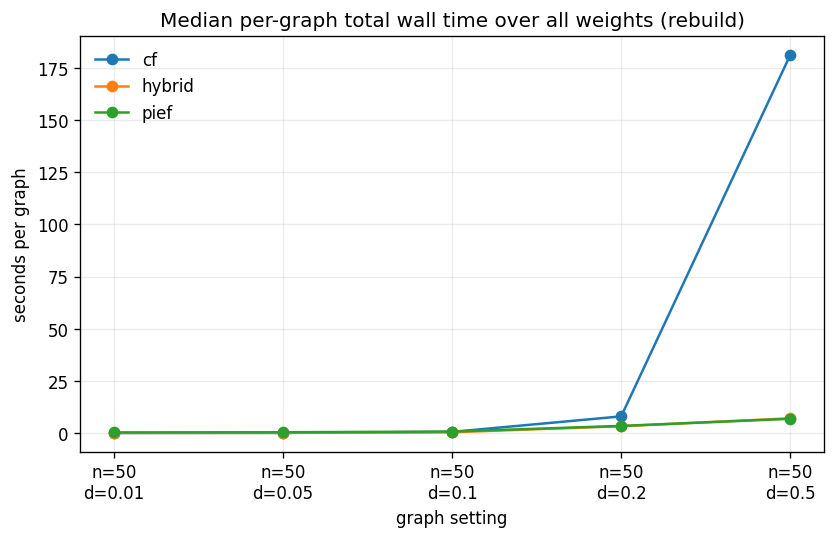

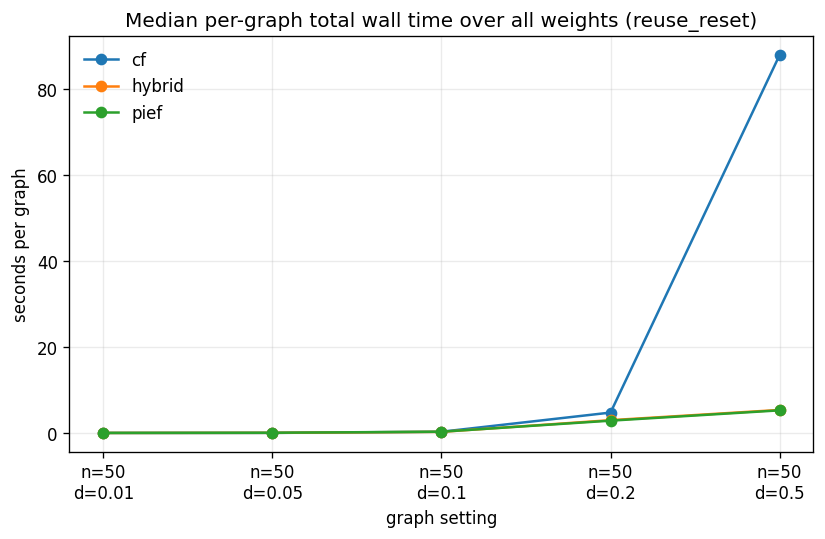

In [15]:
if pd is None:
    print("Install pandas to run this summary plot cell.")
else:
    for mode in sorted(per_graph_summary["mode"].unique()):
        plot_df = per_graph_summary[per_graph_summary["mode"] == mode].copy()
        if plot_df.empty:
            continue
        fig, ax = plt.subplots(figsize=(8, 4.5))
        for formulation in FORMULATIONS:
            sub = plot_df[plot_df["formulation"] == formulation]
            ax.plot(range(len(sub)), sub["median_graph_total_wall"], marker="o", label=formulation)
        ax.set_title(f"Median per-graph total wall time over all weights ({mode})")
        ax.set_ylabel("seconds per graph")
        ax.set_xlabel("graph setting")
        ax.grid(True, alpha=0.25)
        ax.legend(frameon=False)
        unique_settings = plot_df[["num_nodes", "target_density"]].drop_duplicates()
        ax.set_xticks(range(len(unique_settings)))
        ax.set_xticklabels([f"n={int(r.num_nodes)}\nd={r.target_density:g}" for r in unique_settings.itertuples()], rotation=0)
        plt.show()


In [16]:
complexity_cols = [
    "num_nodes",
    "target_density",
    "graph_seed",
    "num_edges",
    "num_cycles",
    "num_chains",
    "num_pief_chain_keys",
    "num_pief_cycle_keys",
]
if pd is None:
    seen = set()
    complexity_rows = []
    for row in as_records(df):
        item = tuple(row.get(col) for col in complexity_cols)
        if item in seen:
            continue
        seen.add(item)
        complexity_rows.append({col: row.get(col) for col in complexity_cols})
    show_table(complexity_rows, n=20)
else:
    complexity_df = df[complexity_cols].drop_duplicates().sort_values(["num_nodes", "target_density", "graph_seed"])
    complexity_df.head(20)


## 9. Winner Map

This winner map uses the per-graph aggregate table, not the per-solve median table. It is only meaningful after the objective consistency check passes and optimal rates are high.


In [17]:
if pd is None:
    print("Install pandas to run the compact winner-map cell.")
else:
    winner = (
        per_graph_summary[per_graph_summary["graph_optimal_rate"] > 0.99]
        .sort_values("median_graph_total_wall")
        .groupby(["mode", "num_nodes", "target_density"], as_index=False)
        .first()
    )
    winner[[
        "mode",
        "num_nodes",
        "target_density",
        "formulation",
        "median_graph_total_wall",
        "median_graph_build_wall",
        "median_graph_solve_wall",
        "graph_optimal_rate",
    ]]


## 10. Next Steps

If the smoke run passes:

1. Increase `NODE_GRID`, `DENSITY_GRID`, `GRAPH_SEEDS`, and `NUM_WEIGHTS` gradually.
2. Keep `objective_consistency_check` as the gatekeeper.
3. Use the per-graph aggregate table as the main runtime comparison for reuse experiments.
4. For long runs, move the same functions into a `.py` runner and execute on `garnet`.
5. Interpret runtime together with `num_chains`, `num_cycles`, `num_pief_chain_keys`, `num_pief_cycle_keys`, `num_vars`, and `num_constrs`.
